In [ ]:
from pathlib import Path

# --------------------------------------------------
# config
# --------------------------------------------------
SUMMARY_PATH = Path("/home/akapociu/ift/interactiondynamics/crcresults/interaction_predictions_falspos_misfires_.10_.10_all_models_all_splits/summary.jsonl")
PLOTS_DIR = Path("./plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Set this yourself if you want a custom export name.
# If None, it will default to the summary folder name.
EXPERIMENT_NAME = None

# Choose whether subplots are grouped by:
# - "dataset_base" : e.g. charged_particles, wave, spring_web_2d
# - "dataset_full" : exact variant names including corruption / threshold metadata
GROUP_DATASETS_BY = "dataset_base"

# SELECTED_DATASETS = [
#     "charged_particles",
#     "springweb",
#     "wave",
# ]
SELECTED_DATASETS = [
    "lastfm",
    "mooc",
    "reddit",
    "wikipedia"
]
AGG_ORDER = ["sum", "ift", "settransformer", "hopfield", "deepsets"]
UPD_ORDER = ["tgn_gru", "ift_update", "hnn", "hopfield_update", "lnn"]

FIGSIZE = (24, 14)
SAVE_FIG = True

In [80]:
import json
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import FormatStrFormatter

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

In [81]:
# --------------------------------------------------
# load summary jsonl
# --------------------------------------------------
rows = []
with SUMMARY_PATH.open("r", encoding="utf-8") as f:
    for line_no, line in enumerate(f, start=1):
        line = line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except json.JSONDecodeError as e:
            print(f"Skipping bad JSON on line {line_no}: {e}")

summary_df = pd.DataFrame(rows)
print(f"Loaded {len(summary_df)} rows from {SUMMARY_PATH}")
display(summary_df.head(3))

Loaded 696 rows from /home/akapociu/ift/interactiondynamics/crcresults/interaction_predictions_falspos_misfires_.10_.10_all_models_all_splits/summary.jsonl


,dataset,run,seed,epochs,best_val_mrr,best_epoch,best_snapshot,final_snapshot,wall_sec,recovery_val,recovery_test,recovery
0,charged_particles_drop=0.10|fake=0.10|splits=train-val-test,charged_particles_drop=0.10|fake=0.10|splits=train-val-test_agg=ift|update=ift_update|do=0.0|sdo=0.0|time=False|softplus|dt=0.05|gamma=0.0|k0=1.0|cap=none,0,3.0,1.0,1.0,"{'epoch': 1, 'train_step': {'loss': 3.044522269388263, 'mrr': 0.2140779300184732, 'kappa_mean': 0.9475401556223966}, 'train_eval': {'loss': 3.044522194380171, 'mrr': 0.9993844979934479, 'steps': 1...","{'epoch': 3, 'train_step': {'loss': 3.044522194380171, 'mrr': 0.9999999876102704, 'kappa_mean': 0.7932410287053397}, 'train_eval': {'loss': 3.044522194380171, 'mrr': 0.9999999876102704, 'steps': 1...",9.334971,"{'loss': 3.0445225303237504, 'mrr': 0.9999999838906366, 'hits@1': 0.9999999838906366, 'hits@10': 0.9999999838906366, 'steps': 37, 'removed_events': 3568}","{'loss': 3.044522523880005, 'mrr': 0.9999999874516537, 'hits@1': 0.9999999874516537, 'hits@10': 0.9999999874516537, 'steps': 38, 'removed_events': 3791}",NaN
1,charged_particles_drop=0.10|fake=0.10|splits=train-val-test,charged_particles_drop=0.10|fake=0.10|splits=train-val-test_agg=ift|update=ift_update|do=0.0|sdo=0.0|time=False|softplus|dt=0.05|gamma=0.0|k0=1.0|cap=none,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'train': {'loss': 3.0445225171828536, 'mrr': 0.999233969141928, 'hits@1': 0.9989404574538885, 'hits@10': 0.999893990125549, 'steps': 178, 'removed_events': 17426}, 'val': {'loss': 3.0445225303237..."
2,charged_particles_drop=0.10|fake=0.10|splits=train-val-test,charged_particles_drop=0.10|fake=0.10|splits=train-val-test_agg=ift|update=tgn_gru|do=0.0|sdo=0.0|time=False,0,3.0,1.0,1.0,"{'epoch': 1, 'train_step': {'loss': 3.044522194380171, 'mrr': 0.9631327732225482}, 'train_eval': {'loss': 3.044522194380171, 'mrr': 0.9999999876102704, 'steps': 178.0, 'early_loss': 3.044522237777...","{'epoch': 3, 'train_step': {'loss': 3.044522194380171, 'mrr': 0.9999999876102704}, 'train_eval': {'loss': 3.044522194380171, 'mrr': 0.9999999876102704, 'steps': 178.0, 'early_loss': 3.044522237777...",7.481088,"{'loss': 3.0445225303237504, 'mrr': 0.9999999838906366, 'hits@1': 0.9999999838906366, 'hits@10': 0.9999999838906366, 'steps': 37, 'removed_events': 3568}","{'loss': 3.044522523880005, 'mrr': 0.9999999874516537, 'hits@1': 0.9999999874516537, 'hits@10': 0.9999999874516537, 'steps': 38, 'removed_events': 3791}",NaN


In [82]:
# --------------------------------------------------
# robust parsers
# --------------------------------------------------
def get_dataset_family(dataset_name):
    """
    Extract the broad dataset family from a dataset variant name.

    Examples
    --------
    charged_particles_drop=0.10|fake=0.10|splits=train-val-test -> charged_particles
    wave_threshold=0.05|target=dv -> wave
    spring_web_2d_force_threshold=0.10|std=True -> spring_web_2d
    """
    if not isinstance(dataset_name, str):
        return None

    first_piece = dataset_name.split("|")[0]

    # strip common variant suffix markers if present
    markers = [
        "_drop=", "_fake=", "_thr=", "_threshold=", "_target=", "_std=", "_pct=",
    ]
    for marker in markers:
        if marker in first_piece:
            first_piece = first_piece.split(marker)[0]

    return first_piece


def parse_run_fields(row):
    dataset = row.get("dataset", None)
    run = row.get("run", "") or row.get("name", "") or ""

    out = {
        "dataset_full": dataset,
        "dataset_base": get_dataset_family(dataset),
        "aggregator": None,
        "update": None,
        "dropout": np.nan,
        "scorer_dropout": np.nan,
        "use_time_features": None,
        "run_dataset_prefix": None,
    }

    if pd.isna(run):
        return pd.Series(out)

    run = str(run)

    # IMPORTANT:
    # split only once at _agg= so pipes inside dataset variant names are preserved
    if "_agg=" in run:
        dataset_part, config_part = run.split("_agg=", 1)
        out["run_dataset_prefix"] = dataset_part
        config_str = "agg=" + config_part
    else:
        config_str = run

    for chunk in config_str.split("|"):
        if "=" not in chunk:
            continue
        key, value = chunk.split("=", 1)
        key = key.strip()
        value = value.strip()

        if key == "agg":
            out["aggregator"] = value
        elif key == "update":
            out["update"] = value
        elif key == "do":
            try:
                out["dropout"] = float(value)
            except ValueError:
                out["dropout"] = np.nan
        elif key == "sdo":
            try:
                out["scorer_dropout"] = float(value)
            except ValueError:
                out["scorer_dropout"] = np.nan
        elif key == "time":
            out["use_time_features"] = value.lower() == "true"

    return pd.Series(out)


def pretty_upd(u):
    return {
        "tgn_gru": "TGN-GRU",
        "lnn": "LNN",
        "hnn": "HNN",
        "hopfield_update": "Hopfield Update",
        "ift_update": "IFT Update",
    }.get(u, u)


def pretty_agg(a):
    return {
        "sum": "Sum",
        "deepsets": "DeepSets",
        "settransformer": "SetTransformer",
        "hopfield": "Hopfield",
        "ift": "IFT",
    }.get(a, a)


def pretty_name(agg, upd):
    return f"{pretty_agg(agg)} / {pretty_upd(upd)}"

In [83]:
# --------------------------------------------------
# enrich summary dataframe
# --------------------------------------------------
parsed = summary_df.apply(parse_run_fields, axis=1)
summary_df = pd.concat([summary_df, parsed], axis=1)

display(
    summary_df[
        [
            "dataset",
            "dataset_full",
            "dataset_base",
            "run",
            "aggregator",
            "update",
            "best_val_mrr",
            "seed",
        ]
    ].head(10)
)

print("Available dataset_full values:")
for ds in sorted(summary_df["dataset_full"].dropna().unique()):
    print("  -", ds)

print("\nAvailable dataset_base values:")
for ds in sorted(summary_df["dataset_base"].dropna().unique()):
    print("  -", ds)

,dataset,dataset_full,dataset_base,run,aggregator,update,best_val_mrr,seed
0,charged_particles_drop=0.10|fake=0.10|splits=train-val-test,charged_particles_drop=0.10|fake=0.10|splits=train-val-test,charged_particles,charged_particles_drop=0.10|fake=0.10|splits=train-val-test_agg=ift|update=ift_update|do=0.0|sdo=0.0|time=False|softplus|dt=0.05|gamma=0.0|k0=1.0|cap=none,ift,ift_update,1.0,0
1,charged_particles_drop=0.10|fake=0.10|splits=train-val-test,charged_particles_drop=0.10|fake=0.10|splits=train-val-test,charged_particles,charged_particles_drop=0.10|fake=0.10|splits=train-val-test_agg=ift|update=ift_update|do=0.0|sdo=0.0|time=False|softplus|dt=0.05|gamma=0.0|k0=1.0|cap=none,ift,ift_update,NaN,0
2,charged_particles_drop=0.10|fake=0.10|splits=train-val-test,charged_particles_drop=0.10|fake=0.10|splits=train-val-test,charged_particles,charged_particles_drop=0.10|fake=0.10|splits=train-val-test_agg=ift|update=tgn_gru|do=0.0|sdo=0.0|time=False,ift,tgn_gru,1.0,0
3,charged_particles_drop=0.10|fake=0.10|splits=train-val-test,charged_particles_drop=0.10|fake=0.10|splits=train-val-test,charged_particles,charged_particles_drop=0.10|fake=0.10|splits=train-val-test_agg=ift|update=tgn_gru|do=0.0|sdo=0.0|time=False,ift,tgn_gru,NaN,0
4,charged_particles_drop=0.10|fake=0.10|splits=train-val-test,charged_particles_drop=0.10|fake=0.10|splits=train-val-test,charged_particles,charged_particles_drop=0.10|fake=0.10|splits=train-val-test_agg=ift|update=lnn|do=0.0|sdo=0.0|time=False,ift,lnn,1.0,0
5,charged_particles_drop=0.10|fake=0.10|splits=train-val-test,charged_particles_drop=0.10|fake=0.10|splits=train-val-test,charged_particles,charged_particles_drop=0.10|fake=0.10|splits=train-val-test_agg=ift|update=lnn|do=0.0|sdo=0.0|time=False,ift,lnn,NaN,0
6,charged_particles_drop=0.10|fake=0.10|splits=train-val-test,charged_particles_drop=0.10|fake=0.10|splits=train-val-test,charged_particles,charged_particles_drop=0.10|fake=0.10|splits=train-val-test_agg=ift|update=hopfield_update|do=0.0|sdo=0.0|time=False,ift,hopfield_update,1.0,0
7,charged_particles_drop=0.10|fake=0.10|splits=train-val-test,charged_particles_drop=0.10|fake=0.10|splits=train-val-test,charged_particles,charged_particles_drop=0.10|fake=0.10|splits=train-val-test_agg=ift|update=hopfield_update|do=0.0|sdo=0.0|time=False,ift,hopfield_update,NaN,0
8,charged_particles_drop=0.10|fake=0.10|splits=train-val-test,charged_particles_drop=0.10|fake=0.10|splits=train-val-test,charged_particles,charged_particles_drop=0.10|fake=0.10|splits=train-val-test_agg=ift|update=hnn|do=0.0|sdo=0.0|time=False,ift,hnn,1.0,0
9,charged_particles_drop=0.10|fake=0.10|splits=train-val-test,charged_particles_drop=0.10|fake=0.10|splits=train-val-test,charged_particles,charged_particles_drop=0.10|fake=0.10|splits=train-val-test_agg=ift|update=hnn|do=0.0|sdo=0.0|time=False,ift,hnn,NaN,0


Available dataset_full values:
  - charged_particles_drop=0.10|fake=0.10|splits=train-val-test
  - lastfm_drop=0.10|fake=0.10|splits=train-val-test
  - mooc_drop=0.10|fake=0.10|splits=train-val-test
  - reddit_drop=0.10|fake=0.10|splits=train-val-test
  - springweb_drop=0.10|fake=0.10|splits=train-val-test
  - wave_drop=0.10|fake=0.10|splits=train-val-test
  - wikipedia_drop=0.10|fake=0.10|splits=train-val-test

Available dataset_base values:
  - charged_particles
  - lastfm
  - mooc
  - reddit
  - springweb
  - wave
  - wikipedia


In [84]:
# --------------------------------------------------
# choose subplot datasets
# --------------------------------------------------
group_col = GROUP_DATASETS_BY
if group_col not in ["dataset_base", "dataset_base"]:
    raise ValueError("GROUP_DATASETS_BY must be 'dataset_full' or 'dataset_base'")

available = summary_df[group_col].dropna().unique().tolist()

if SELECTED_DATASETS is None:
    DATASET_ORDER = sorted(available)[:4]
else:
    DATASET_ORDER = list(SELECTED_DATASETS)
    missing = [ds for ds in DATASET_ORDER if ds not in set(available)]
    if missing:
        raise ValueError(
            f"These requested datasets were not found in {group_col}: {missing}"
        )

print("Grouping datasets by:", group_col)
print("DATASET_ORDER:")
for ds in DATASET_ORDER:
    print("  -", ds)

Grouping datasets by: dataset_base
DATASET_ORDER:
  - charged_particles
  - springweb
  - wave


In [85]:
# --------------------------------------------------
# aggregate across seeds
# --------------------------------------------------
metrics_df = (
    summary_df
    .dropna(subset=[group_col, "aggregator", "update", "best_val_mrr"])
    .groupby([group_col, "aggregator", "update"], as_index=False)
    .agg(
        avg_val_mrr=("best_val_mrr", "mean"),
        std_val_mrr=("best_val_mrr", "std"),
        n_seeds=("seed", "count"),
    )
)

rank_all_by_dataset = {
    ds: subdf.copy().sort_values("avg_val_mrr", ascending=False).reset_index(drop=True)
    for ds, subdf in metrics_df.groupby(group_col)
}

display(metrics_df.head(20))

,dataset_base,aggregator,update,avg_val_mrr,std_val_mrr,n_seeds
0,charged_particles,deepsets,hnn,1.00000,0.000000,2
1,charged_particles,deepsets,hopfield_update,1.00000,0.000000,2
2,charged_particles,deepsets,ift_update,1.00000,0.000000,2
3,charged_particles,deepsets,lnn,0.18891,0.000024,2
4,charged_particles,deepsets,tgn_gru,1.00000,0.000000,2
5,charged_particles,hopfield,hnn,1.00000,0.000000,2
6,charged_particles,hopfield,hopfield_update,1.00000,0.000000,2
7,charged_particles,hopfield,ift_update,1.00000,0.000000,2
8,charged_particles,hopfield,lnn,1.00000,0.000000,2
9,charged_particles,hopfield,tgn_gru,1.00000,0.000000,2


In [86]:
def short_dataset_label(ds):
    if not isinstance(ds, str):
        return str(ds)

    # first strip variant metadata after pipes
    base = ds.split("|")[0]

    # strip common suffix markers
    for marker in ["_drop=", "_fake=", "_thr=", "_threshold=", "_target=", "_std=", "_pct="]:
        if marker in base:
            base = base.split(marker)[0]

    # optional pretty names
    pretty_map = {
        "spring_web": "Spring Web",
        "charged_particles": "Charged Particles",
        "wave": "Wave",
    }

    return pretty_map.get(base, base)

Saved figure to: plots/interaction_predictions_falspos_misfires_.10_.10_all_models_all_splits_grouped_by_dataset_base_bar.png


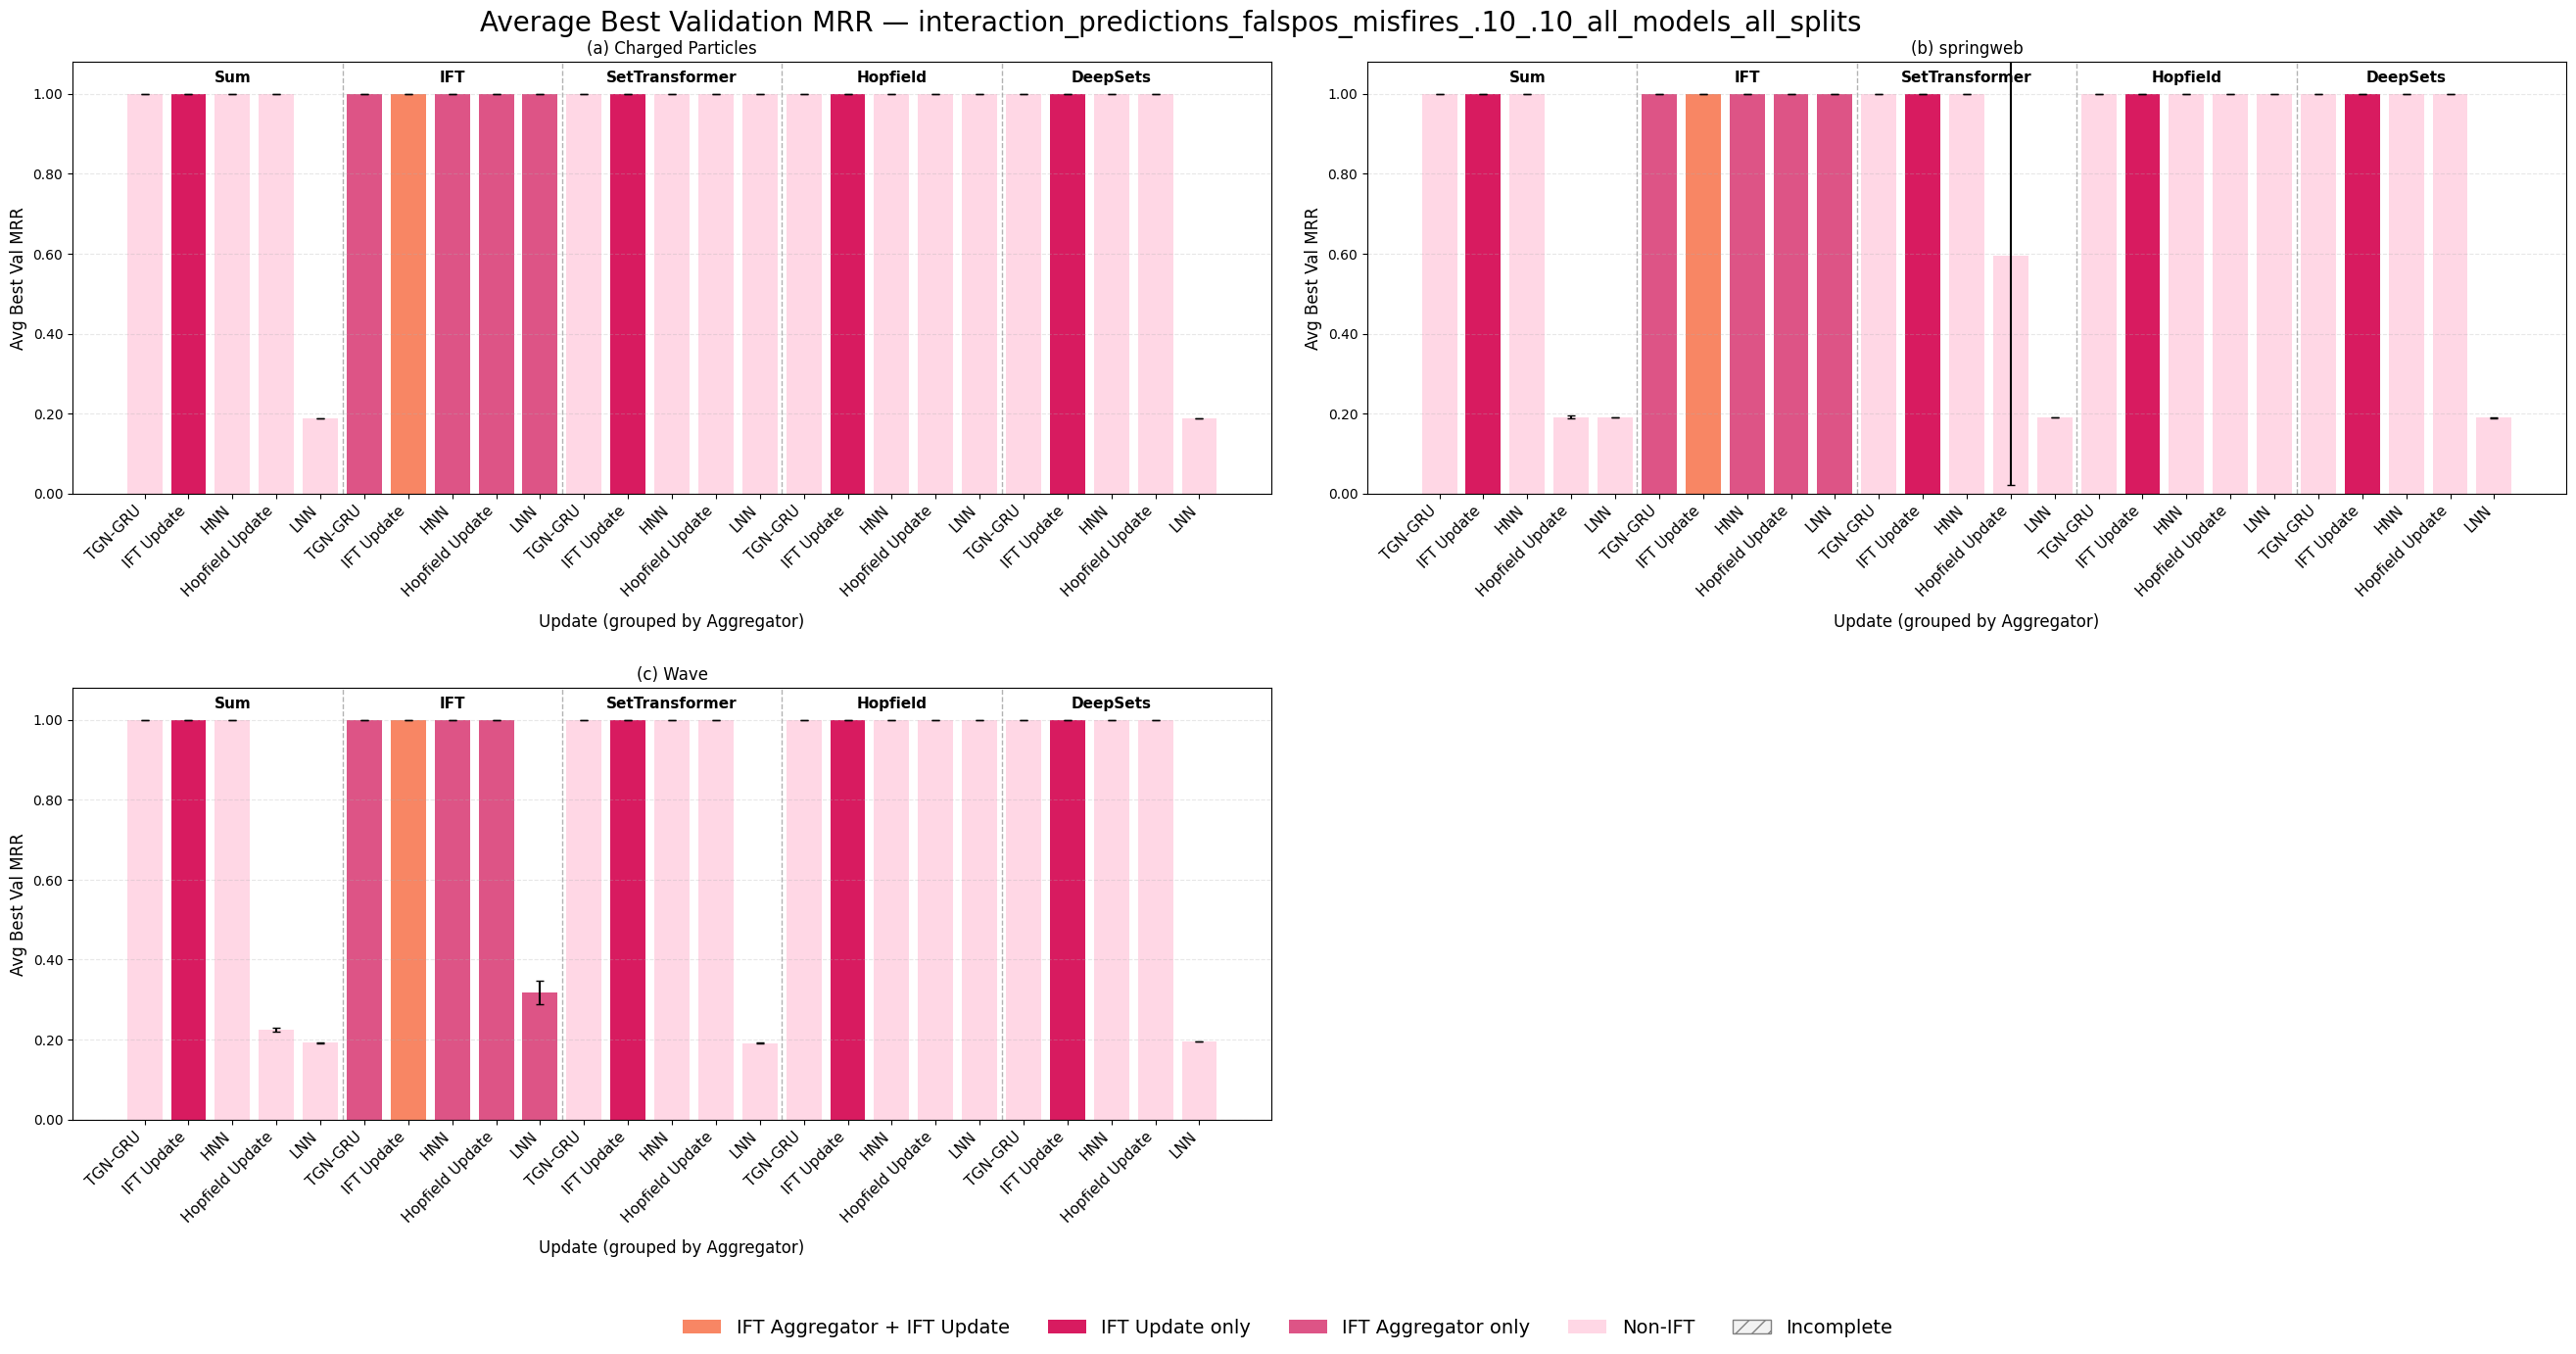

In [87]:
# --------------------------------------------------
# grouped subplot figure
# --------------------------------------------------
n_panels = len(DATASET_ORDER)
ncols = 2
nrows = math.ceil(n_panels / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=FIGSIZE, sharey=False)
axes = np.array(axes).reshape(-1)

labels_abcd = [f"({chr(ord('a') + i)})" for i in range(n_panels)]

full_index = pd.MultiIndex.from_product(
    [AGG_ORDER, UPD_ORDER],
    names=["aggregator", "update"]
)
full_df = pd.DataFrame(index=full_index).reset_index()

for ax, ds, panel_label in zip(axes, DATASET_ORDER, labels_abcd):
    focus_df = rank_all_by_dataset.get(ds, pd.DataFrame()).copy()

    df_full = full_df.merge(focus_df, on=["aggregator", "update"], how="left")

    df_full["aggregator"] = pd.Categorical(
        df_full["aggregator"], categories=AGG_ORDER, ordered=True
    )
    df_full["update"] = pd.Categorical(
        df_full["update"], categories=UPD_ORDER, ordered=True
    )
    df_full = df_full.sort_values(["aggregator", "update"]).reset_index(drop=True)

    x = np.arange(len(df_full))
    y = df_full["avg_val_mrr"].values
    err = df_full["std_val_mrr"].fillna(0).values
    labels = [pretty_upd(u) for u in df_full["update"]]

    bar_heights = np.nan_to_num(y, nan=0.0)
    bars = ax.bar(x, bar_heights, yerr=err, capsize=3)

    for i, (bar, upd, agg, val) in enumerate(
        zip(bars, df_full["update"], df_full["aggregator"], y)
    ):
        if pd.isna(val):
            bar.set_facecolor("#f2f2f2")
            bar.set_edgecolor("gray")
            bar.set_hatch("//")
            bar.set_linewidth(1.0)

            ax.text(
                i, 0.02, "Incomplete",
                rotation=90,
                ha="center",
                va="bottom",
                fontsize=8,
                color="gray"
            )
        else:
            if (upd == "ift_update") and (agg == "ift"):
                bar.set_facecolor("#f88664")
            elif upd == "ift_update":
                bar.set_facecolor("#d81b60")
            elif agg == "ift":
                bar.set_facecolor("#dd5486")
            else:
                bar.set_facecolor("#ffd7e5")

    # separator lines between aggregator groups
    for boundary in [4.5, 9.5, 14.5, 19.5]:
        ax.axvline(boundary, color="gray", linestyle="--", linewidth=1, alpha=0.6)

    # aggregator labels pinned to top-inside of axes
    group_centers = [2, 7, 12, 17, 22]
    group_names = [pretty_agg(a) for a in AGG_ORDER]
    for xc, gname in zip(group_centers, group_names):
        ax.text(
            xc,
            0.98,
            gname,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=11,
            fontweight="bold"
        )

    ax.set_title(f"{panel_label} {short_dataset_label(ds)}")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=11)
    ax.set_ylabel("Avg Best Val MRR", fontsize=12)
    ax.set_xlabel("Update (grouped by Aggregator)", fontsize=12, labelpad=10)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    # Give a little headroom so bars/err don't kiss the top
    ax.set_ylim(0, 1.08)
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

# turn off any unused axes
for ax in axes[n_panels:]:
    ax.axis("off")

legend_elements = [
    Patch(facecolor="#f88664", label="IFT Aggregator + IFT Update"),
    Patch(facecolor="#d81b60", label="IFT Update only"),
    Patch(facecolor="#dd5486", label="IFT Aggregator only"),
    Patch(facecolor="#ffd7e5", label="Non-IFT"),
    Patch(facecolor="#f2f2f2", edgecolor="gray", hatch="//", label="Incomplete"),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=5,
    frameon=False,
    fontsize=14
)
experiment_name = EXPERIMENT_NAME if EXPERIMENT_NAME is not None else SUMMARY_PATH.parent.name
fig.suptitle(f"Average Best Validation MRR — {experiment_name}", fontsize=20)

fig.tight_layout(rect=[0, 0.06, 1.1, 1])
fig.subplots_adjust(hspace=0.45, wspace=0.08)

if SAVE_FIG:
    out_path = PLOTS_DIR / f"{experiment_name}_grouped_by_{group_col}_bar.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print("Saved figure to:", out_path)

plt.show()

In [88]:
# --------------------------------------------------
# optional ranking table export
# --------------------------------------------------
ranking_rows = []
for ds in DATASET_ORDER:
    focus = rank_all_by_dataset.get(ds)
    if focus is None or focus.empty:
        continue
    tmp = focus.copy()
    tmp.insert(0, group_col, ds)
    ranking_rows.append(tmp)

ranking_df = pd.concat(ranking_rows, ignore_index=True) if ranking_rows else pd.DataFrame()
display(ranking_df)

if not ranking_df.empty:
    experiment_name = EXPERIMENT_NAME if EXPERIMENT_NAME is not None else SUMMARY_PATH.parent.name
    csv_path = PLOTS_DIR / f"{experiment_name}_rankings_{group_col}.csv"
    ranking_df.to_csv(csv_path, index=False)
    print("Saved rankings to:", csv_path)

ValueError: cannot insert dataset_base, already exists